In [35]:
# Preparing imports
import pandas as pd
import matplotlib.pyplot as plt 

In [36]:
import numpy as np
import pandas as pd

print(np.__version__)
print(pd.__version__)

2.5.1
3.0.5


In [37]:
# Checking lookup table

# Importing the date lookup table
lookup = pd.read_csv("AirBnB_date_lookup.csv")
city_filter = "Christchurch City"


In [38]:
merged_data = []

# Actual loop over the files and appending chch data to the object
for row in lookup.itertuples(index = False): # using itertuples to go over rows instead of cols (the default)
    df = pd.read_csv(f"../data/{row.name}") # getting the file name from the lookup table
    df = df[df["neighbourhood_group"] == city_filter]
    df["year_month"] = row.year_month # getting year-month from the lookup table
    merged_data.append(df)

# Finally merging via concat
merged_data = pd.concat(merged_data, ignore_index = True)

#merged_data

#Extra check
assert (merged_data["neighbourhood_group"] == city_filter).all(), \
    "Non-Christchurch listings detected — filtering step failed."

### Filtering for Duplicates

In [39]:
df = combined_airbnb
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,year_month
0,968224198043666870,Room,516048910.0,Heer,Christchurch City,Innes Ward,-43.49815,172.65054,Private room,64.0,1.0,0,NaN,NaN,1.0,89,0,NaN,2026-6
1,24742386,Garden Studio With Ensuite (Breakfast included),43654083.0,Kathy,Christchurch City,Papanui Ward,-43.50407,172.59607,Entire home/apt,172.0,1.0,205,2026-05-19,2.31,1.0,241,36,NaN,2026-6
2,1654821509215926144,Papanui Oasis Entire House,754856789.0,Jonathan Allan,Christchurch City,Papanui Ward,-43.48954,172.61408,Entire home/apt,230.0,1.0,5,2026-05-16,2.24,1.0,335,5,NaN,2026-6
3,7403587,Warm Cosy Quiet Home Semi Rural,38795211.0,Wendy,Christchurch City,Halswell Ward,-43.57605,172.54686,Private room,143.0,1.0,0,NaN,NaN,1.0,263,0,NaN,2026-6
4,22570965,One Bedroom Apartment,44728588.0,Anita Marie,Christchurch City,Papanui Ward,-43.48606,172.61688,Hotel room,202.0,1.0,3,2022-04-27,0.03,6.0,342,0,NaN,2026-6


In [40]:
num_unique_ids = df["id"].nunique()
num_rows = len(df["id"])


print(num_unique_ids)
print(num_rows)

4117
28795


In [41]:
id_reapeats = df["id"].value_counts()

df["id"].value_counts().value_counts().sort_index()



count
1     215
2     243
3     253
4     249
5     216
6     204
7     199
8     200
9    2338
Name: count, dtype: int64

### Understanding the ID's and unique Identifiers 

The data set was Christchurch AirBnB data collected from October 2025 to June 2026. The time frame spans 9 months; hence, there are 2338 unique ideas that have a price recording for everymonth in the dataset. The remaining, 1,779 IDs are missing at least one month. Of these 1,779 215 are missing 8 months.  

In [42]:
price_counts = df.groupby("id")["price"].count()

price_counts.value_counts().sort_index()

price
0     163
1     283
2     514
3     246
4     548
5     291
6    2072
Name: count, dtype: int64

In [43]:
df.groupby("year_month")["price"].agg(
    total_rows="size",
    prices_recorded="count",
    prices_missing=lambda x: x.isna().sum()
)

,total_rows,prices_recorded,prices_missing
year_month,,,
2025-10,2991,2821,170
2025-11,3047,2835,212
2025-12,3180,0,3180
2026-1,3057,0,3057
2026-2,3190,0,3190
2026-3,3227,3059,168
2026-4,3273,3069,204
2026-5,3361,3149,212
2026-6,3469,3195,274


I had the suspision that there might be missingess based on month in the datset. The code above confirmed my suspision that there were no price recordings for December, January, and February. Hence, it is impossible for all 9 months to have a price recording, even though they do have observations. It is still unclear how we are going to proceed with the assignment. In the future, if we are modeling to predict the outcome variable price, all observations in December through Febuary will have to be removed as there will be no observation associated with the outcome variable. 

In [44]:
id_counts = df["id"].value_counts()

example_id = id_counts.index[0]

df[df["id"] == example_id]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,year_month
0,968224198043666870,Room,516048910.0,Heer,Christchurch City,Innes Ward,-43.49815,172.65054,Private room,64.0,1.0,0,NaN,NaN,1.0,89,0,NaN,2026-6
3532,968224198043666870,Room,516048910.0,Heer,Christchurch City,Innes Ward,-43.49815,172.65054,Private room,64.0,1.0,0,NaN,NaN,1.0,89,0,NaN,2026-5
8109,968224198043666870,Room,516048910.0,Heer,Christchurch City,Innes Ward,-43.49815,172.65054,Private room,64.0,1.0,0,NaN,NaN,1.0,89,0,NaN,2026-4
11388,968224198043666870,Room,516048910.0,Heer,Christchurch City,Innes Ward,-43.49815,172.65054,Private room,64.0,1.0,0,NaN,NaN,1.0,89,0,NaN,2026-3
13452,968224198043666870,Room,516048910.0,Heer,Christchurch City,Innes Ward,-43.49815,172.65054,Private room,NaN,1.0,0,NaN,NaN,1.0,89,0,NaN,2026-2
16582,968224198043666870,Room,516048910.0,Heer,Christchurch City,Innes Ward,-43.49815,172.65054,Private room,NaN,1.0,0,NaN,NaN,1.0,89,0,NaN,2026-1
19807,968224198043666870,Room,516048910.0,Heer,Christchurch City,Innes Ward,-43.49815,172.65054,Private room,NaN,1.0,0,NaN,NaN,1.0,89,0,NaN,2025-12
22968,968224198043666870,Room,516048910.0,Heer,Christchurch City,Innes Ward,-43.49815,172.65054,Private room,56.0,1.0,0,NaN,NaN,1.0,89,0,NaN,2025-11
25880,968224198043666870,Room,516048910.0,Heer,Christchurch City,Innes Ward,-43.49815,172.65054,Private room,NaN,1.0,0,NaN,NaN,1.0,89,0,NaN,2025-10


In [45]:
# Threshold (%) used to flag incomplete rows; must match data_cleaning.md
MISSINGNESS_THRESHOLD = 50

# Calculate the percentage of missing values in each row
row_missing_percent = combined_airbnb.isnull().mean(axis=1) * 100

# Filter rows at or above the threshold
high_missing_rows = combined_airbnb[row_missing_percent >= MISSINGNESS_THRESHOLD].copy()

# Add the percent missing to the filtered dataframe
high_missing_rows["percent_missing"] = row_missing_percent[row_missing_percent >= MISSINGNESS_THRESHOLD]

# Sort from highest to lowest percent missing
high_missing_rows = high_missing_rows.sort_values(
    "percent_missing",
    ascending=False
)

# Display number of rows and the dataframe
print(f"Number of rows with {MISSINGNESS_THRESHOLD}% or more missing: {len(high_missing_rows)}")

high_missing_rows

Number of rows with 60% or more missing: 0


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,year_month,percent_missing


No observations contained 50% or more missing values. There are no severe incomplete rows within the dataset. Despite this, there are still missing values for price that are month based. 

In [46]:
# Missingess by Percentage for each column in the dataset 
missingness_percentage = df.isnull().mean()*100
missingness_percentage

id                                  0.000000
name                                0.000000
host_id                             0.000000
host_name                           0.003473
neighbourhood_group                 0.000000
neighbourhood                       0.000000
latitude                            0.000000
longitude                           0.000000
room_type                           0.000000
price                              37.044626
minimum_nights                      0.128495
number_of_reviews                   0.000000
last_review                         9.123112
reviews_per_month                   9.123112
calculated_host_listings_count      0.000000
availability_365                    0.000000
number_of_reviews_ltm               0.000000
license                           100.000000
year_month                          0.000000
dtype: float64

### Checking the Names to Ensure there are not accidental duplicates 

In [47]:
possible_matches = (
    df.groupby(["host_id", "latitude", "longitude"])["id"]
      .nunique()
      .reset_index(name="num_ids")
)

possible_matches = possible_matches[possible_matches["num_ids"] > 1]

possible_matches

,host_id,latitude,longitude,num_ids
254,20665858.0,-43.811981,172.959442,4
260,20665858.0,-43.809784,172.961329,3
263,20665858.0,-43.809403,172.962080,2
300,23278101.0,-43.524851,172.636000,2
336,24205506.0,-43.534032,172.642502,2
...,...,...,...,...
3950,662706872.0,-43.568466,172.542489,3
4033,682808597.0,-43.520189,172.645666,2
4035,686294777.0,-43.530661,172.638537,3
4140,731795588.0,-43.539121,172.634407,2


In [48]:
# Setting data data type
df["year_month"] = pd.to_datetime(df["year_month"], format = "%Y-%m")

# Sorting df on id year and month
df = df.sort_values(["id", "year_month"])

df[df["id"] == 968224198043666870]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,year_month
25880,968224198043666870,Room,516048910.0,Heer,Christchurch City,Innes Ward,-43.49815,172.65054,Private room,NaN,1.0,0,NaN,NaN,1.0,89,0,NaN,2025-10-01
22968,968224198043666870,Room,516048910.0,Heer,Christchurch City,Innes Ward,-43.49815,172.65054,Private room,56.0,1.0,0,NaN,NaN,1.0,89,0,NaN,2025-11-01
19807,968224198043666870,Room,516048910.0,Heer,Christchurch City,Innes Ward,-43.49815,172.65054,Private room,NaN,1.0,0,NaN,NaN,1.0,89,0,NaN,2025-12-01
16582,968224198043666870,Room,516048910.0,Heer,Christchurch City,Innes Ward,-43.49815,172.65054,Private room,NaN,1.0,0,NaN,NaN,1.0,89,0,NaN,2026-01-01
13452,968224198043666870,Room,516048910.0,Heer,Christchurch City,Innes Ward,-43.49815,172.65054,Private room,NaN,1.0,0,NaN,NaN,1.0,89,0,NaN,2026-02-01
11388,968224198043666870,Room,516048910.0,Heer,Christchurch City,Innes Ward,-43.49815,172.65054,Private room,64.0,1.0,0,NaN,NaN,1.0,89,0,NaN,2026-03-01
8109,968224198043666870,Room,516048910.0,Heer,Christchurch City,Innes Ward,-43.49815,172.65054,Private room,64.0,1.0,0,NaN,NaN,1.0,89,0,NaN,2026-04-01
3532,968224198043666870,Room,516048910.0,Heer,Christchurch City,Innes Ward,-43.49815,172.65054,Private room,64.0,1.0,0,NaN,NaN,1.0,89,0,NaN,2026-05-01
0,968224198043666870,Room,516048910.0,Heer,Christchurch City,Innes Ward,-43.49815,172.65054,Private room,64.0,1.0,0,NaN,NaN,1.0,89,0,NaN,2026-06-01


### Finding Possible Matches Based on Similarity 

In [49]:
matched_rows = df.merge(
    possible_matches[["host_id", "latitude", "longitude"]],
    on=["host_id", "latitude", "longitude"],
    how="inner"
)

matched = matched_rows[
    ["id", "name", "host_id", "host_name",
     "latitude", "longitude", "room_type", "year_month", "last_review"]
].sort_values(["host_id", "latitude", "longitude", "year_month"])


Adam = matched[matched["host_id"] == 20665858.0]

Adam.head(20)

Adam_sort = Adam.sort_values(["year_month"])

Adam_sort




,id,name,host_id,host_name,latitude,longitude,room_type,year_month,last_review
1172,1235618546202635230,Waterfront 2-Bedroom Harbour View Apartment,20665858.0,Adam,-43.809784,172.961329,Entire home/apt,2025-10-01,2025-09-27
1511,1381269607476367188,Peaceful 2-Bedroom Retreat with Harbour Outlook,20665858.0,Adam,-43.809784,172.961329,Entire home/apt,2025-10-01,2025-09-22
1847,1535899869404546607,Central Akaroa 2 bedroom ground floor apartment,20665858.0,Adam,-43.809403,172.962080,Entire home/apt,2025-11-01,2025-10-25
1173,1235618546202635230,Waterfront 2-Bedroom Harbour View Apartment,20665858.0,Adam,-43.809784,172.961329,Entire home/apt,2025-11-01,2025-10-20
1512,1381269607476367188,Peaceful 2-Bedroom Retreat with Harbour Outlook,20665858.0,Adam,-43.809784,172.961329,Entire home/apt,2025-11-01,2025-11-06
1869,1548685874596111956,Central Akaroa 2 bedroom upstairs apartment,20665858.0,Adam,-43.809403,172.962080,Entire home/apt,2025-12-01,2025-12-06
1848,1535899869404546607,Central Akaroa 2 bedroom ground floor apartment,20665858.0,Adam,-43.809403,172.962080,Entire home/apt,2025-12-01,2025-12-04
1513,1381269607476367188,Peaceful 2-Bedroom Retreat with Harbour Outlook,20665858.0,Adam,-43.809784,172.961329,Entire home/apt,2025-12-01,2025-12-02
1174,1235618546202635230,Waterfront 2-Bedroom Harbour View Apartment,20665858.0,Adam,-43.809784,172.961329,Entire home/apt,2025-12-01,2025-11-21
1849,1535899869404546607,Central Akaroa 2 bedroom ground floor apartment,20665858.0,Adam,-43.809403,172.962080,Entire home/apt,2026-01-01,2026-01-19


In [50]:
matched.head(20)

,id,name,host_id,host_name,latitude,longitude,room_type,year_month,last_review
1518,1381269607476367188,Peaceful 2-Bedroom Retreat with Harbour Outlook,20665858.0,Adam,-43.811981,172.959442,Entire home/apt,2026-05-01,2026-04-23
1725,1500374157679491336,1-Bedroom Retreat with Spa Bath & Harbour Outlook,20665858.0,Adam,-43.811981,172.959442,Entire home/apt,2026-05-01,2026-05-05
2089,1632995279176460732,Groundfloor Waterfront 2Bed Harbour View Apart...,20665858.0,Adam,-43.811981,172.959442,Entire home/apt,2026-05-01,2026-05-03
2142,1680136570718571666,Waterfront 2-Bedroom Harbour View Apartment,20665858.0,Adam,-43.811981,172.959442,Entire home/apt,2026-05-01,NaN
1519,1381269607476367188,Peaceful 2-Bedroom Retreat with Harbour Outlook,20665858.0,Adam,-43.811981,172.959442,Entire home/apt,2026-06-01,2026-05-23
1726,1500374157679491336,1-Bedroom Retreat with Spa Bath & Harbour Outlook,20665858.0,Adam,-43.811981,172.959442,Entire home/apt,2026-06-01,2026-06-01
2090,1632995279176460732,Groundfloor Waterfront 2Bed Harbour View Apart...,20665858.0,Adam,-43.811981,172.959442,Entire home/apt,2026-06-01,2026-05-31
2143,1680136570718571666,Waterfront 2-Bedroom Harbour View Apartment,20665858.0,Adam,-43.811981,172.959442,Entire home/apt,2026-06-01,2026-05-30
1172,1235618546202635230,Waterfront 2-Bedroom Harbour View Apartment,20665858.0,Adam,-43.809784,172.961329,Entire home/apt,2025-10-01,2025-09-27
1511,1381269607476367188,Peaceful 2-Bedroom Retreat with Harbour Outlook,20665858.0,Adam,-43.809784,172.961329,Entire home/apt,2025-10-01,2025-09-22


### Vizualizing Outliers

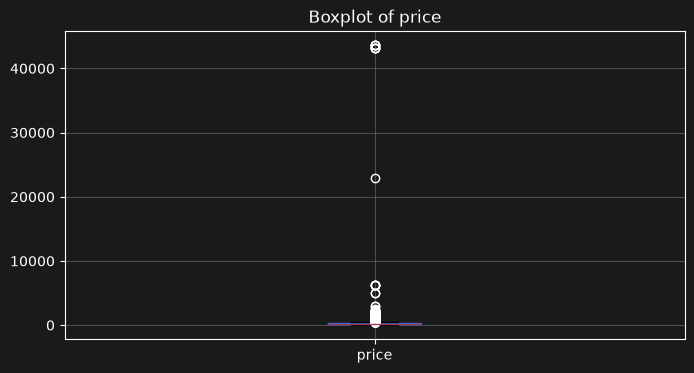

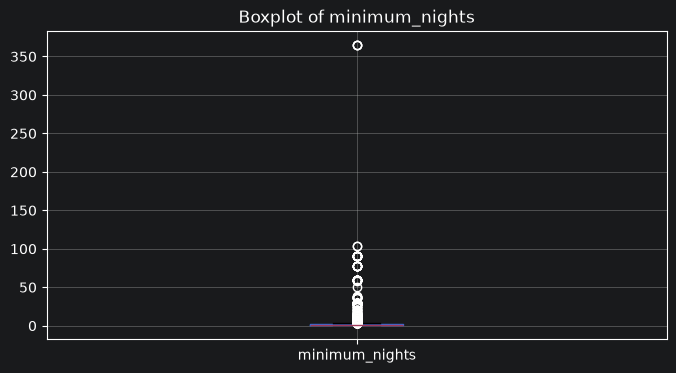

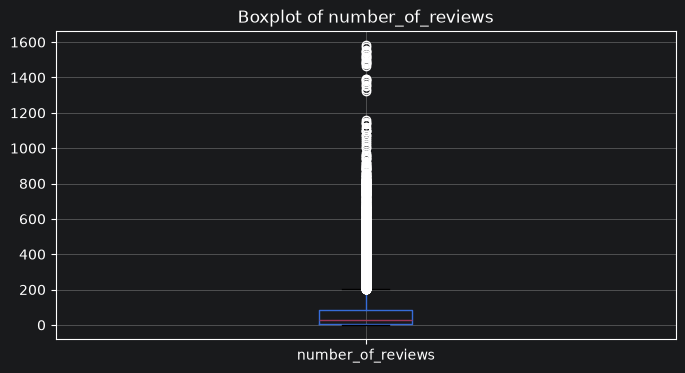

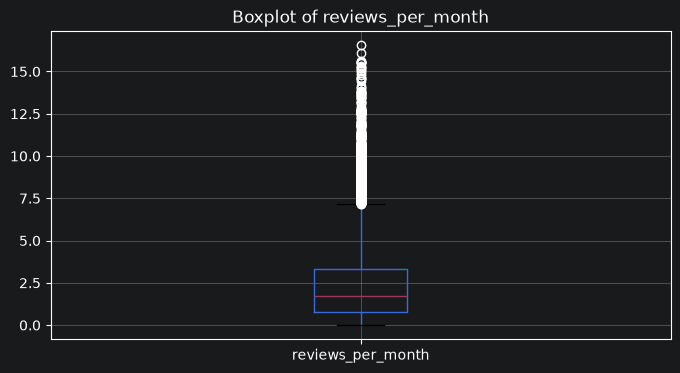

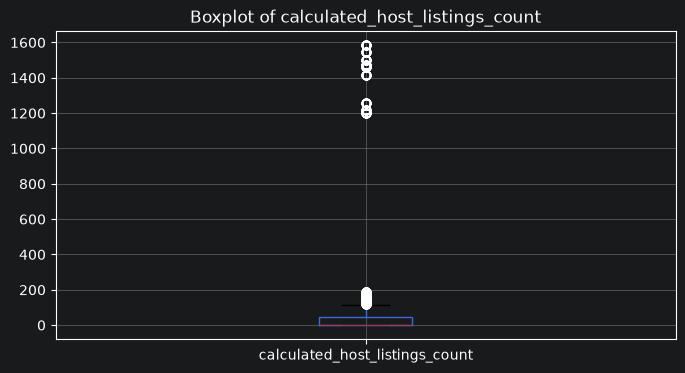

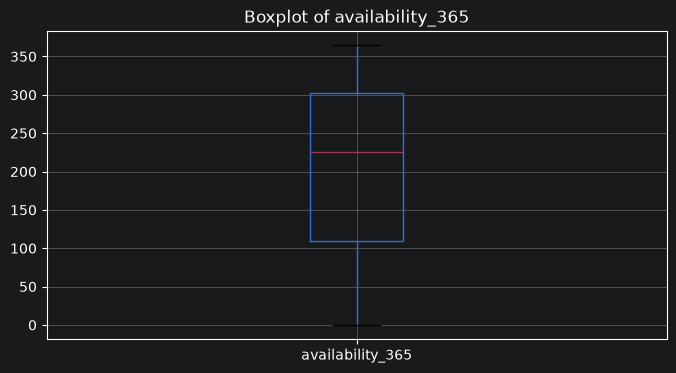

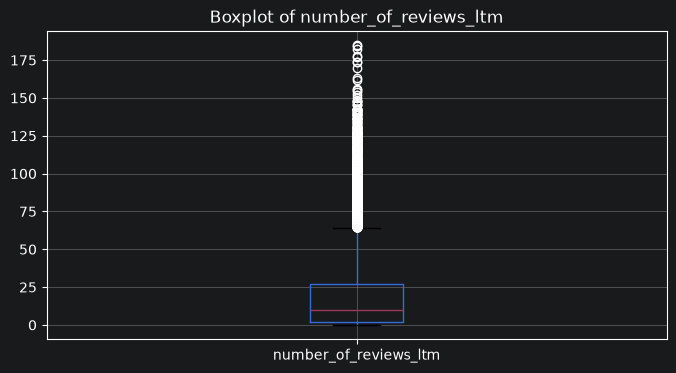

In [51]:
#removing columns that have no meaningful context for outliers 
exclude_cols = ["id", "host_id", "latitude", "longitude", "license"]

#Keeping only the numeric columns 
numeric = merged_data.select_dtypes(include = "number").columns

for col in numeric:
    if col not in exclude_cols:
        plt.figure (figsize = (8,4))
        merged_data.boxplot(column = col)
        plt.title(f"Boxplot of {col}")
        plt.show

In [52]:
exclude_cols = ["id", "host_id", "latitude", "longitude", "license"]

numeric = merged_data.select_dtypes(include="number").columns

# Dictionary to store each outlier dataframe
outlier_dfs = {}

for col in numeric:
    if col not in exclude_cols:
        
        Q1 = merged_data[col].quantile(0.25)
        Q3 = merged_data[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = merged_data[
            (merged_data[col] < lower_bound) |
            (merged_data[col] > upper_bound)
        ]
        
        # Save dataframe
        outlier_dfs[col] = outliers
        
        print(f"{col}: {len(outliers)} outliers")

price: 947 outliers
minimum_nights: 1076 outliers
number_of_reviews: 2373 outliers
reviews_per_month: 1063 outliers
calculated_host_listings_count: 4928 outliers
availability_365: 0 outliers
number_of_reviews_ltm: 1727 outliers


In [53]:
outlier_dfs["price"].head(50)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,year_month
11,1697552554418003873,Sumner beach Art house,1.695168e+18,Jodi Ann,Christchurch City,Heathcote Ward,-43.572360,172.765255,Entire home/apt,742.0,1.0,0,NaN,NaN,1.0,299,0,NaN,2026-6
16,44339855,Central Lyttelton - sleeps 10,2.964051e+08,Gary,Christchurch City,Banks Peninsula Ward,-43.603310,172.722229,Entire home/apt,627.0,1.0,10,2023-03-19,0.16,5.0,332,0,NaN,2026-6
20,868364088455534956,Studio B Sumner - Christchurch,8.139084e+07,Perfect Stays,Christchurch City,Heathcote Ward,-43.567330,172.758340,Entire home/apt,516.0,1.0,6,2025-09-13,0.22,27.0,72,1,NaN,2026-6
40,1631566348510658018,Fresh sunshine house : close to Airport.,7.488743e+08,Jiali,Christchurch City,Hornby Ward,-43.522600,172.539510,Entire home/apt,531.0,1.0,0,NaN,NaN,2.0,321,0,NaN,2026-6
46,1689517300319261783,Spacious Hornby Stay | 3BR | Sleeps 8 | Garage,1.237764e+08,Aj,Christchurch City,Hornby Ward,-43.547560,172.537957,Entire home/apt,514.0,1.0,0,NaN,NaN,2.0,350,0,NaN,2026-6
61,1391046801701974472,Seaside sanctuary with spa,1.469124e+07,Chris,Christchurch City,Banks Peninsula Ward,-43.795939,172.918495,Entire home/apt,810.0,2.0,30,2026-05-31,2.25,1.0,308,29,NaN,2026-6
104,26848494,Land Sea Adventure,8.338195e+07,Anji,Christchurch City,Banks Peninsula Ward,-43.604210,172.690760,Entire home/apt,543.0,5.0,7,2026-01-17,0.09,2.0,333,2,NaN,2026-6
133,1308819791396386806,Retreats Workshops or Gatherings,1.299697e+07,Jane,Christchurch City,Banks Peninsula Ward,-43.788358,172.820480,Entire home/apt,1028.0,2.0,0,NaN,NaN,6.0,338,0,NaN,2026-6
147,30237340,Bond Estate Luxury Accommodation Christchurch,2.270814e+08,Garry,Christchurch City,Hornby Ward,-43.521690,172.504320,Entire home/apt,1265.0,1.0,50,2026-03-29,0.55,1.0,221,3,NaN,2026-6
150,8144885,Cass Bay House,1.033940e+07,Vivienne,Christchurch City,Banks Peninsula Ward,-43.604610,172.694800,Entire home/apt,559.0,3.0,17,2026-04-10,0.22,3.0,182,2,NaN,2026-6


In [54]:
# Adding the quarter here so the exported file already has it; the downstream
# Koordinates and quarterly notebooks rely on this column
df["quarter"] = df["year_month"].dt.to_period("Q")

df.to_csv("cleaned_chch_airbnb.csv", index=False)

In [55]:
import os
print(os.getcwd())

C:\Users\maria\OneDrive\Desktop\DATA422\Christchurch-Rentals-Data-2026\workflows


In [56]:
# Setting data data type
df["year_month"] = pd.to_datetime(df["year_month"], format = "%Y-%m")

# Sorting df on id year and month
df = df.sort_values(["id", "year_month"])

# Setting date to quarterly 
df["quarter"] = df["year_month"].dt.to_period("Q")

# Grouping on Id and date 
df_group = df.groupby(["id", "quarter"])
df_group.head()


df_quarterly = df_group.agg(
    year_month = ("year_month", "first"),
    price = ("price", "mean"),
    number_of_reviews = ("number_of_reviews", "max"),
    minimum_nights = ("minimum_nights", "mean"),
    host_id = ("host_id", "first"),
    host_name = ("host_name", "first"),
    latitude = ("latitude", "first"),
    longitude = ("longitude", "first"),
    room_type = ("room_type", "first"),
    
    ). reset_index()



df_quarterly

,id,quarter,year_month,price,number_of_reviews,minimum_nights,host_id,host_name,latitude,longitude,room_type
0,204050,2025Q4,2025-10-01,96.5,8,13.0,976173.0,Ian,-43.511480,172.596580,Private room
1,319770,2025Q4,2025-10-01,112.0,3,1.0,1639584.0,Jennifer,-43.509610,172.655520,Private room
2,319770,2026Q1,2026-01-01,198.0,3,1.0,1639584.0,Jennifer,-43.509610,172.655520,Private room
3,319770,2026Q2,2026-04-01,198.0,3,1.0,1639584.0,Jennifer,-43.509610,172.655520,Private room
4,737452,2025Q4,2025-10-01,330.0,99,2.0,3851282.0,Susan Margaret,-43.823430,172.946430,Entire home/apt
...,...,...,...,...,...,...,...,...,...,...,...
10350,1709707140933674458,2026Q2,2026-06-01,90.0,0,1.0,298456605.0,Tony,-43.517010,172.689100,Private room
10351,1709717077595636126,2026Q2,2026-06-01,237.0,0,1.0,74811135.0,Maggie,-43.550180,172.637020,Entire home/apt
10352,1709766634414326200,2026Q2,2026-06-01,216.0,0,1.0,482671075.0,Care Property Stays,-43.521041,172.651563,Entire home/apt
10353,1709787994531999473,2026Q2,2026-06-01,92.0,0,1.0,111299485.0,Kerry,-43.566887,172.627699,Private room


In [57]:
id_reapeats = df_quarterly["id"].value_counts()

df_quarterly["id"].value_counts().value_counts().sort_index()

count
1     650
2     696
3    2771
Name: count, dtype: int64

In [58]:
# Exporting the quarterly table (previously this exported the monthly df by mistake)
df_quarterly.to_csv("cleaned_chch_airbnb_quarterly.csv", index=False)